In [1]:
pip install pandas numpy matplotlib seaborn plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.9 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.9 MB 3.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.7/9.9 MB 3.7 MB/s eta 0:00:02
   ----------------- ---------------------- 4.5/9.9 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.9 MB/s eta 0:00:02
   --------------------------- ------------ 6.8/9.9 MB 4.2 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 4.4 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
os.getcwd()

'c:\\Users\\cw\\OneDrive\\Pictures\\Desktop\\Documents\\USND\\notebooks'

In [7]:
import os
os.listdir("../data")

['DisasterDeclarations.csv']

Load the data set

In [8]:
df = pd.read_csv("../data/DisasterDeclarations.csv")

Check Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69634 entries, 0 to 69633
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   femaDeclarationString     69634 non-null  object
 1   disasterNumber            69634 non-null  int64 
 2   state                     69634 non-null  object
 3   declarationType           69634 non-null  object
 4   declarationDate           69634 non-null  object
 5   fyDeclared                69634 non-null  int64 
 6   incidentType              69634 non-null  object
 7   declarationTitle          69634 non-null  object
 8   ihProgramDeclared         69634 non-null  int64 
 9   iaProgramDeclared         69634 non-null  int64 
 10  paProgramDeclared         69634 non-null  int64 
 11  hmProgramDeclared         69634 non-null  int64 
 12  incidentBeginDate         69634 non-null  object
 13  incidentEndDate           68801 non-null  object
 14  disasterCloseoutDate  

describe the data

In [10]:
df.describe()

,disasterNumber,fyDeclared,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared,tribalRequest,fipsStateCode,fipsCountyCode,placeCode,declarationRequestNumber,incidentId,region
count,69634.000000,69634.000000,69634.000000,69634.000000,69634.000000,69634.000000,69634.000000,69634.000000,69634.000000,69634.000000,69634.000000,6.963400e+04,69634.000000
mean,2714.136370,2005.946391,0.167045,0.246819,0.935621,0.431126,0.002398,31.394836,97.684522,96472.979450,34189.613278,1.609792e+09,5.178835
std,1437.694226,15.202781,0.373019,0.431164,0.245429,0.495237,0.048914,16.627488,102.131093,13660.356858,33657.667364,1.244842e+09,2.112520
min,1.000000,1953.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.000000,5.300300e+04,1.000000
25%,1392.250000,1998.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,31.000000,99029.000000,9081.000000,9.806600e+04,4.000000
50%,3190.000000,2008.000000,0.000000,0.000000,1.000000,0.000000,0.000000,29.000000,75.000000,99073.000000,20062.000000,2.008100e+09,5.000000
75%,4015.000000,2020.000000,0.000000,0.000000,1.000000,1.000000,0.000000,46.000000,127.000000,99125.000000,72034.000000,2.020031e+09,7.000000
max,5621.000000,2026.000000,1.000000,1.000000,1.000000,1.000000,1.000000,78.000000,840.000000,99507.000000,99159.000000,9.062400e+09,10.000000


Checking missing values

In [11]:
df.isnull().sum()

femaDeclarationString           0
disasterNumber                  0
state                           0
declarationType                 0
declarationDate                 0
fyDeclared                      0
incidentType                    0
declarationTitle                0
ihProgramDeclared               0
iaProgramDeclared               0
paProgramDeclared               0
hmProgramDeclared               0
incidentBeginDate               0
incidentEndDate               833
disasterCloseoutDate        16373
tribalRequest                   0
fipsStateCode                   0
fipsCountyCode                  0
placeCode                       0
designatedArea                  0
declarationRequestNumber        0
lastIAFilingDate            50201
incidentId                      0
region                          0
designatedIncidentTypes     47812
lastRefresh                     0
hash                            0
id                              0
dtype: int64

check data shape

In [12]:
df.shape

(69634, 28)

Convert Date Columns

In [13]:
df['declarationDate'] = pd.to_datetime(df['declarationDate'])
df['incidentBeginDate'] = pd.to_datetime(df['incidentBeginDate'])
df['incidentEndDate'] = pd.to_datetime(df['incidentEndDate'])

Create Year and Month Columns

In [14]:
df['year'] = df['declarationDate'].dt.year
df['month'] = df['declarationDate'].dt.month

Basic Exploration

In [15]:
year_counts = df.groupby('year').size()

year_counts.head()

year
1953    13
1954    17
1955    18
1956    16
1957    16
dtype: int64

In [16]:
state_counts = df['state'].value_counts()

state_counts.head()

state
TX    5388
KY    3355
MO    2830
FL    2791
GA    2765
Name: count, dtype: int64

In [17]:
incident_counts = df['incidentType'].value_counts()

incident_counts

incidentType
Severe Storm           19299
Hurricane              13721
Flood                  11234
Biological              7857
Fire                    3853
Snowstorm               3707
Severe Ice Storm        2956
Tornado                 1623
Drought                 1292
Winter Storm            1224
Tropical Storm          1059
Coastal Storm            637
Other                    314
Freezing                 301
Earthquake               228
Typhoon                  130
Volcanic Eruption         51
Mud/Landslide             44
Fishing Losses            42
Dam/Levee Break           13
Tsunami                    9
Toxic Substances           9
Chemical                   9
Human Cause                7
Tropical Depression        7
Terrorist                  5
Straight-Line Winds        3
Name: count, dtype: int64

Visualization 1 - Disaster Declarations Over Time

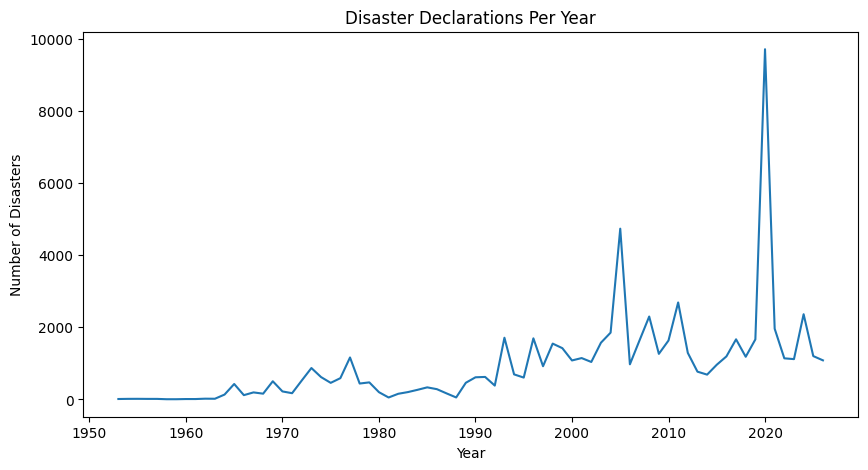

In [18]:
plt.figure(figsize=(10,5))

year_counts.plot()

plt.title("Disaster Declarations Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.show()

Visualization 2 - Top States with Most Disasters

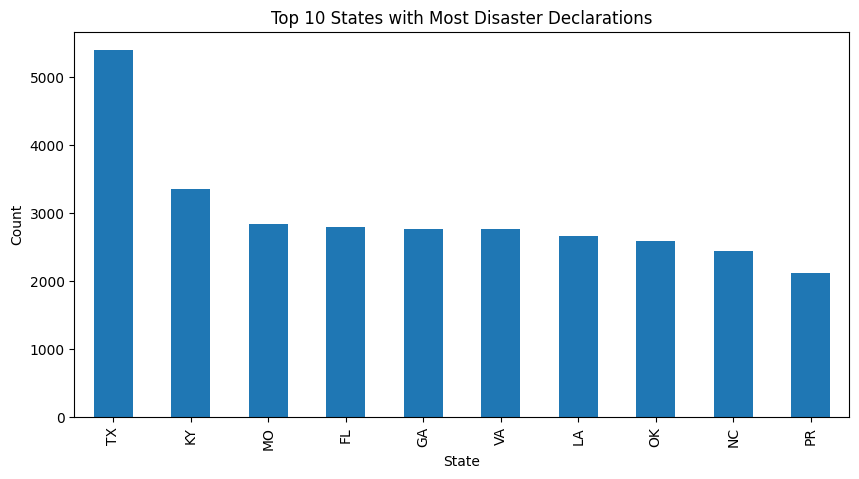

In [19]:
plt.figure(figsize=(10,5))

state_counts.head(10).plot(kind='bar')

plt.title("Top 10 States with Most Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Count")

plt.show()

Visualization 3 - Incident Type Distribution

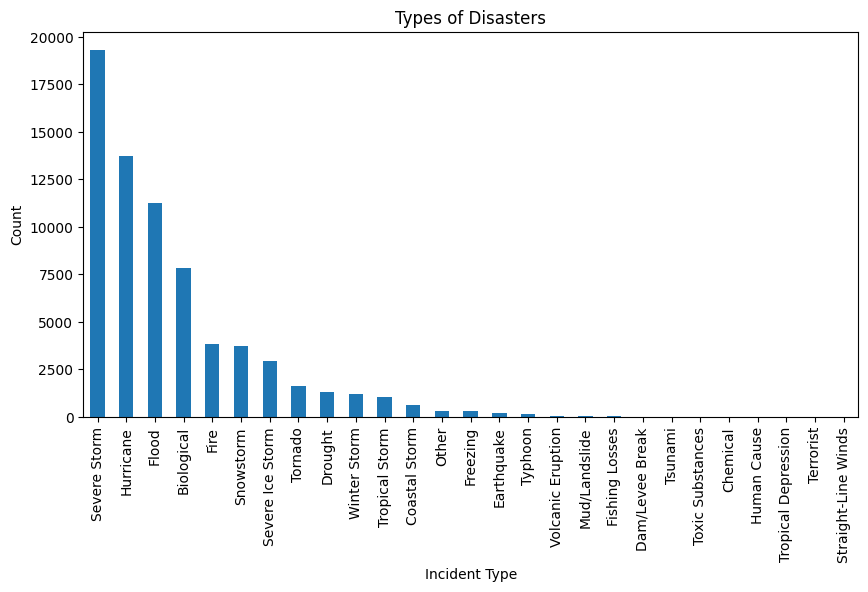

In [20]:
plt.figure(figsize=(10,5))

incident_counts.plot(kind='bar')

plt.title("Types of Disasters")
plt.xlabel("Incident Type")
plt.ylabel("Count")

plt.show()